In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df=pd.read_excel("Blinkit_Grocery.xlsx")

In [72]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [73]:
df.shape

(8523, 12)

In [74]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


# Data Cleaning

In [76]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [77]:
df['Item_Weight']=df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [78]:
df['Outlet_Size']=df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [79]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

# duplicates

In [80]:
df['Item_Identifier'].duplicated().sum()

np.int64(6964)

In [81]:
df['Item_Identifier'].nunique()

1559

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [84]:
df['Item_Outlet_Sales'].describe()

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

In [85]:
df.tail(15)
# df.head(20)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,Medium,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,Medium,Tier 3,Grocery Store,424.7804
8510,FDN58,13.800,Regular,0.056862,Snack Foods,231.5984,OUT035,2004,Small,Tier 2,Supermarket Type1,7182.6504
8511,FDF05,17.500,Low Fat,0.026980,Frozen Foods,262.5910,OUT018,2009,Medium,Tier 3,Supermarket Type2,4207.8560
8512,FDR26,20.700,Low Fat,0.042801,Dairy,178.3028,OUT013,1987,High,Tier 3,Supermarket Type1,2479.4392
8513,FDH31,12.000,Regular,0.020407,Meat,99.9042,OUT035,2004,Small,Tier 2,Supermarket Type1,595.2252
8514,FDA01,15.000,Regular,0.054489,Canned,57.5904,OUT045,2002,Medium,Tier 2,Supermarket Type1,468.7232
8515,FDH24,20.700,Low Fat,0.021518,Baking Goods,157.5288,OUT018,2009,Medium,Tier 3,Supermarket Type2,1571.2880
8516,NCJ19,18.600,Low Fat,0.118661,Others,58.7588,OUT018,2009,Medium,Tier 3,Supermarket Type2,858.8820
8517,FDF53,20.750,reg,0.083607,Frozen Foods,178.8318,OUT046,1997,Small,Tier 1,Supermarket Type1,3608.6360


In [86]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('reg','Regular')
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('LF','Low Fat')
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('low fat','Low Fat')

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


# **EDA (Exploratory Data Analysis)**

**1.Total Revenue**

In [88]:
df['Item_Outlet_Sales'].sum() 

np.float64(18591125.4104)

**2. Average Sales Value**

In [89]:
df['Item_Outlet_Sales'].mean() #Average Sales

np.float64(2181.288913575032)

**3.Which Category Has Most Poducts ?**

In [90]:
df['Item_Type'].value_counts().sort_values(ascending=False)

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

# **"VISUALIZATION"**

# **1. TOTAL SALES BY ITEM TYPE**

In [91]:
df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Breads                   5.532372e+05
Hard Drinks              4.577934e+05
Starchy Foods            3.514013e+05
Others                   3.255176e+05
Breakfast                2.322990e+05
Seafood                  1.488682e+05
Name: Item_Outlet_Sales, dtype: float64

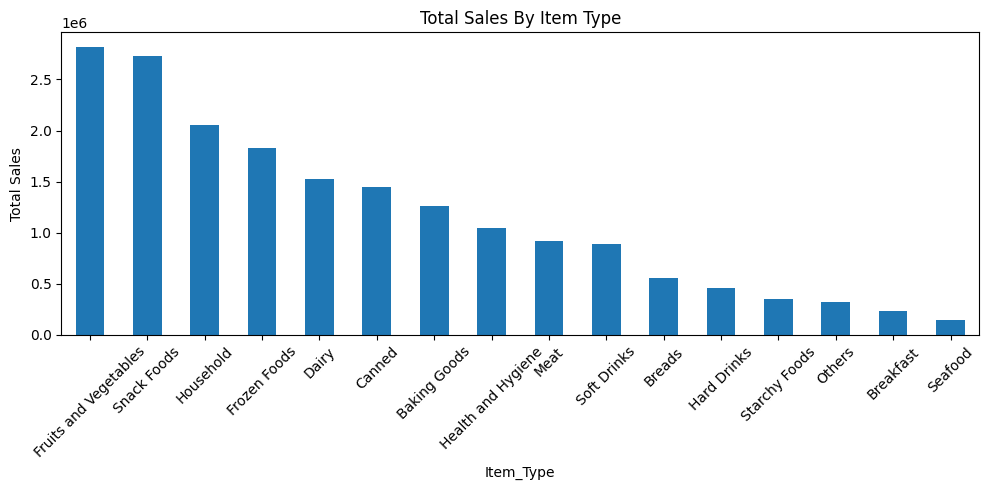

In [92]:
df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(10,5))
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.xlabel("Item_Type")
plt.title("Total Sales By Item Type")
plt.tight_layout()
plt.show()

**INSIGHTS: Sales are Led by Fruits & Vegetables And Snack Foods, With Seafood Contributing the least, showing clear category Performance gaps to address**

# **2.TOTAL SALES BY FAT CONTENT**

In [93]:
df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

Item_Fat_Content
Low Fat    1.190409e+07
Regular    6.687031e+06
Name: Item_Outlet_Sales, dtype: float64

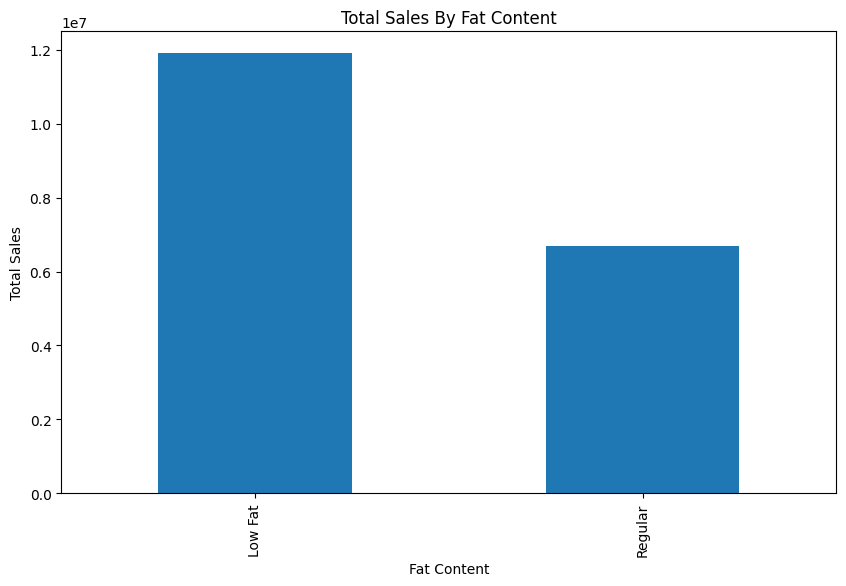

In [94]:
df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(10,6))
plt.title("Total Sales By Fat Content")
plt.ylabel("Total Sales")
plt.xlabel("Fat Content")
plt.show()


# INSIGHTS

**LOW  Fat products outsell Regular products by nearly 2:1, indicating strong customer preference for healthier options that should drive future inventory and marketing focus**

# **3.TOTAL SALES BY OUTLET SIZE**

In [95]:
df.groupby('Outlet_Size')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

Outlet_Size
Medium    1.188225e+07
Small     4.566212e+06
High      2.142664e+06
Name: Item_Outlet_Sales, dtype: float64

Text(0, 0.5, 'Total_Sales')

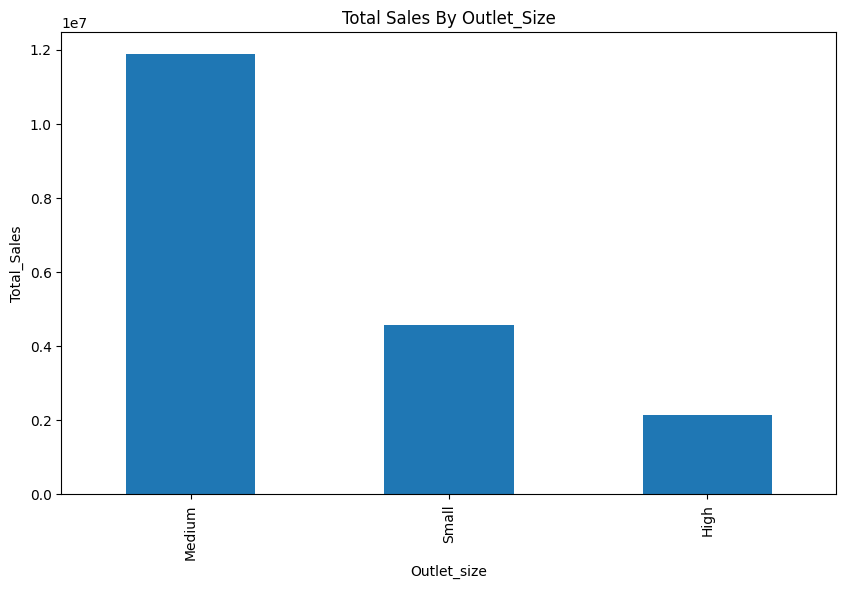

In [96]:
df.groupby('Outlet_Size')['Item_Outlet_Sales'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(10,6))
plt.title("Total Sales By Outlet_Size")
plt.xlabel("Outlet_size")
plt.ylabel("Total_Sales")


# INSIGHTS

**Medium-sized outlets drive 2.5x more total sales than Small outlets and 5x more than High outlets, making them the most effective format for revenue generation**

# **4.TOTAL SALES BY OUTLET LOCATION TYPE**

In [97]:
df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

Outlet_Location_Type
Tier 3    7.636753e+06
Tier 2    6.472314e+06
Tier 1    4.482059e+06
Name: Item_Outlet_Sales, dtype: float64

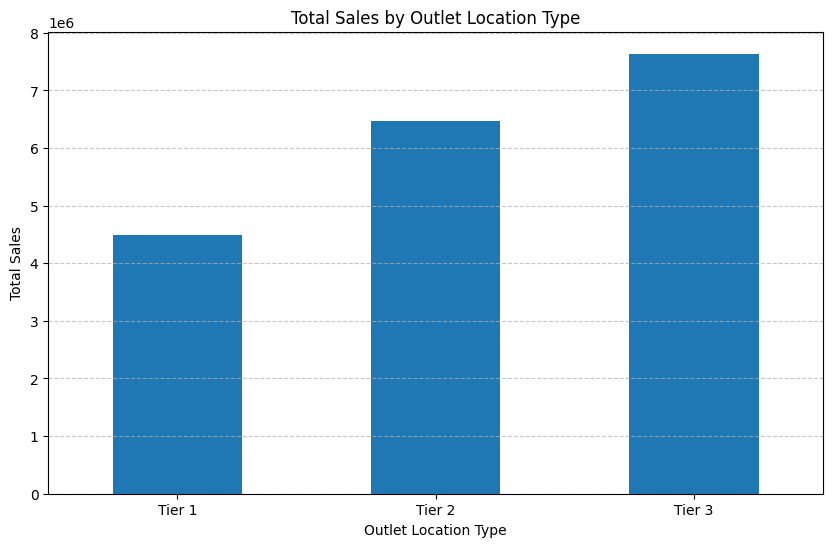

In [98]:
df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().plot(kind='bar',figsize=(10,6))
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.xlabel('Outlet Location Type')
plt.title("Total Sales by Outlet Location Type")
plt.show()

# INSIGHTS

**Tier 3 locations generate the highest total sales, significantly outperforming Tier 1, indicating stronger market demand or better performance in smaller cities.**

#  **5.AVERAGE SALES BY ITEM TYPE**

In [99]:
df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64

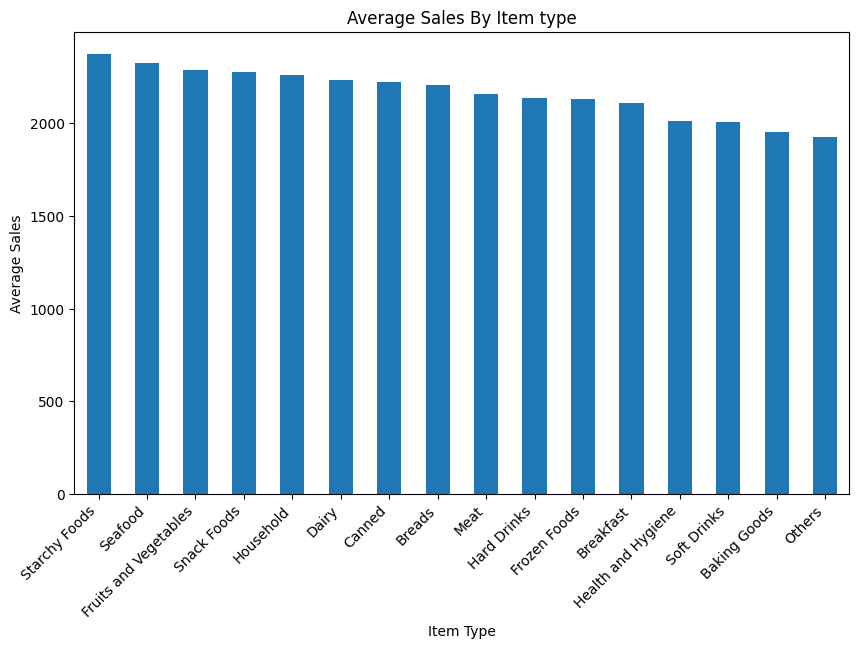

In [100]:
df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,6))
plt.xlabel("Item Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=45,ha='right')
plt.title("Average Sales By Item type")
plt.show()


# INSIGHTS

**Seafood and Starchy Foods have the highest average sales per item, showing high value per SKU despite lower total volume**

# **6.Top Performing Items**

In [101]:
df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False).head(10)

Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Name: Item_Outlet_Sales, dtype: float64

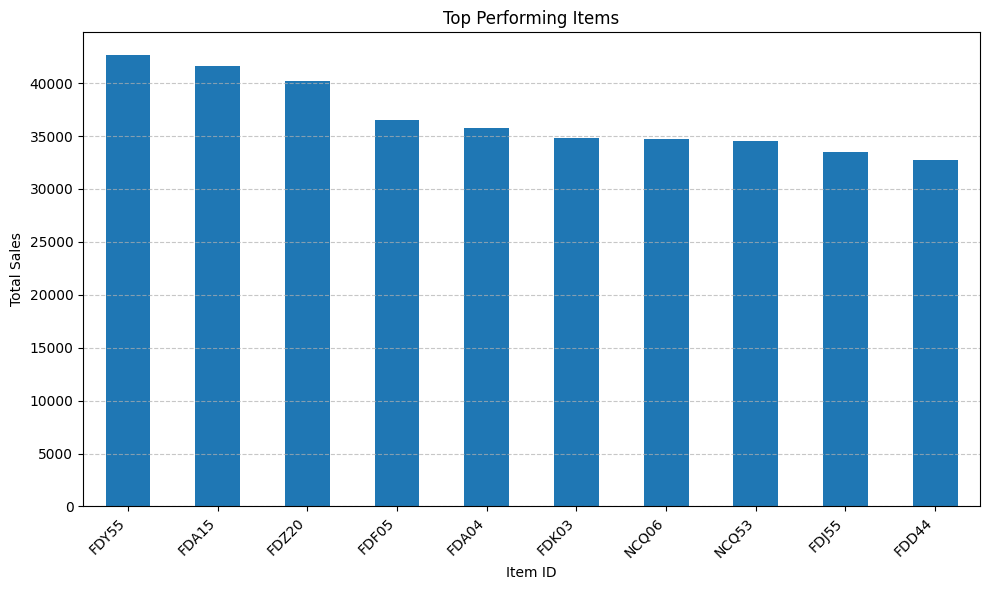

In [102]:
df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(10,6))
plt.title("Top Performing Items")
plt.xlabel("Item ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

In [103]:
df.to_csv('Cleaned_BlinkitGrocery.csv',index=False)

# INSIGHTS

**Top 2 categories drive 2.8x more sales than the bottom 2 in this chart, so inventory and promotions should focus on Fruits & Vegetables and Snack Foods**

# CONCLUSIONS

# **1. Project Overview**
# - Performed data cleaning and EDA on Blinkit Grocery dataset
# - Saved cleaned dataset into CSV format

# **2. Key Insights**
# - FDY55 generated highest sales
# - Fruits & Vegetables and Snack Foods are top categories
# - Large sales gap exists between top and low performing items

# **3. Business Recommendations**
# - Maintain stock for top-selling products
# - Focus marketing on high revenue categories
# - Review low-performing products